# 04 — Model selection under protocol v2 (FD001–FD004)

**Purpose:** pick one model specification per dataset on training engines only, under the rules
pre-registered in `reports/model_selection.md` (D51), and lock it — or leave two candidates
pending where the rules do not separate them.
**Questions:** 1 how far selection moved the headline · 2 is cap 90 an artefact of the metric ·
3 which addendum blocks survived · 4 LSTM sequence length and channels · 5 what tuning bought ·
6 which adopted changes survive 5 seeds · 7 XGBoost or LSTM, and is it locked.
**Data version:** DVC hash of `data/raw`, printed below. **Outputs:** figures in
`reports/figures/model_selection/`; the specs in `specs/` are written by the orchestrator and
read here. **Decisions informed:** D01, D07, D08, D10, D21–D25, D35, D51, D52.
**Status:** current. The NASA test set is never read (rule 3).

In [ ]:
from __future__ import annotations

import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from turbofan import tracking
from turbofan.pipeline.selection import Spec

REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SEL = REPO / "reports" / "selection"
FIG = REPO / "reports" / "figures" / "model_selection"
FIG.mkdir(parents=True, exist_ok=True)
DATASETS = ["FD001", "FD002", "FD003", "FD004"]
HEAD = "critical_rmse"
pd.set_option("display.width", 200, "display.max_colwidth", 80)

git = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=REPO, capture_output=True,
                     text=True, check=True).stdout.strip()
print(f"data/raw DVC hash: {tracking._dvc_data_hash()}")
print(f"git commit: {git}")
print("source: reports/selection/*.json (every number below is read, none recomputed)")

E:\turbofan-rul-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


data/raw DVC hash: 43f328008844d7fd56733c63103d09ef.dir
git commit: 01f6cb1
source: reports/selection/*.json (every number below is read, none recomputed)


In [ ]:
def load(stage: str, ds: str) -> dict:
    return json.loads((SEL / f"stage_{stage}_{ds}.json").read_text(encoding="utf-8"))


def ci(est: float, lo: float, hi: float, p: int = 2) -> str:
    return f"{est:.{p}f} [{lo:.{p}f}, {hi:.{p}f}]"


def headline(doc: dict, tag: str) -> tuple[float, float, float, int, int]:
    m = next(iter(doc["configs"][tag]["models"].values()))
    return m[HEAD], m[f"{HEAD}_ci_lo"], m[f"{HEAD}_ci_hi"], m["n_engines"], m["n_splits"]


def comparisons(stage: str, prefix: str = "") -> pd.DataFrame:
    rows = []
    for ds in DATASETS:
        for r in load(stage, ds)["comparisons"]:
            if r["substage"].startswith(prefix):
                verdict = "better" if r["better"] else ("worse" if r["worse"] else "not different")
                rows.append({"dataset": ds, "step": r["substage"], "metric": r.get("metric", HEAD),
                             "challenger": r["challenger"], "incumbent": r["incumbent"],
                             "Δ [95% CI]": ci(r["diff"], r["diff_ci_lo"], r["diff_ci_hi"]),
                             "n engines": r["n_engines"], "verdict": verdict,
                             "_lo": r["diff_ci_lo"], "_hi": r["diff_ci_hi"]})
    return pd.DataFrame(rows)


def show(df: pd.DataFrame) -> pd.DataFrame:
    return df[[c for c in df.columns if not c.startswith("_")]]

## 1. How far did selection move the headline?

**Question:** what deployment-view critical RMSE does each stage's candidate reach, starting from
the original default (cap 125, window 20, base features, untuned XGBoost)?
**Method:** each stage's adopted spec, read from its run; CIs are 1,000-replicate engine
bootstraps. Stages A–C use seed 42 only, Stage D five seeds, so only Stage D ranks models.

In [ ]:
rows = []
for ds in DATASETS:
    a = load("A", ds)
    stages = [
        ("original default", a, f"A/{ds}/cap125"),
        ("Stage A XGBoost", a, a["winners"]["stage_A_tag"]),
    ]
    x, b, c, d = (load(s, ds) for s in "XBCD")
    stages.append(("Stage X XGBoost (re-run)", x, Spec.from_json(x["specs"]["xgboost"]).tag))
    stages.append(("Stage B LSTM", b, Spec.from_json(b["specs"]["lstm"]).tag))
    for m in ("xgboost", "lstm"):
        stages.append((f"Stage C {m}", c, Spec.from_json(c["specs"][m]).tag))
    for m in ("xgboost", "lstm"):
        stages.append((f"Stage D {m} (5 seeds)", d, Spec.from_json(d["specs"][m]).tag))
    for name, doc, tag in stages:
        est, lo, hi, n, k = headline(doc, tag)
        rows.append({"dataset": ds, "candidate": name, "est": est, "lo": lo, "hi": hi,
                     "critical RMSE [95% CI]": ci(est, lo, hi), "n engines": n, "n splits": k})
prog = pd.DataFrame(rows)
show(prog.drop(columns=["est", "lo", "hi"]))

,dataset,candidate,critical RMSE [95% CI],n engines,n splits
0,FD001,original default,"5.19 [4.78, 5.64]",100,15
1,FD001,Stage A XGBoost,"3.41 [3.05, 3.76]",100,15
2,FD001,Stage X XGBoost (re-run),"3.41 [3.06, 3.73]",100,15
3,FD001,Stage B LSTM,"3.56 [3.22, 3.93]",100,15
4,FD001,Stage C xgboost,"3.22 [2.87, 3.58]",100,15
5,FD001,Stage C lstm,"3.02 [2.75, 3.35]",100,15
6,FD001,Stage D xgboost (5 seeds),"3.27 [2.90, 3.62]",100,75
7,FD001,Stage D lstm (5 seeds),"3.25 [2.97, 3.57]",100,75
8,FD002,original default,"5.93 [5.58, 6.32]",260,15
9,FD002,Stage A XGBoost,"3.92 [3.63, 4.21]",260,15


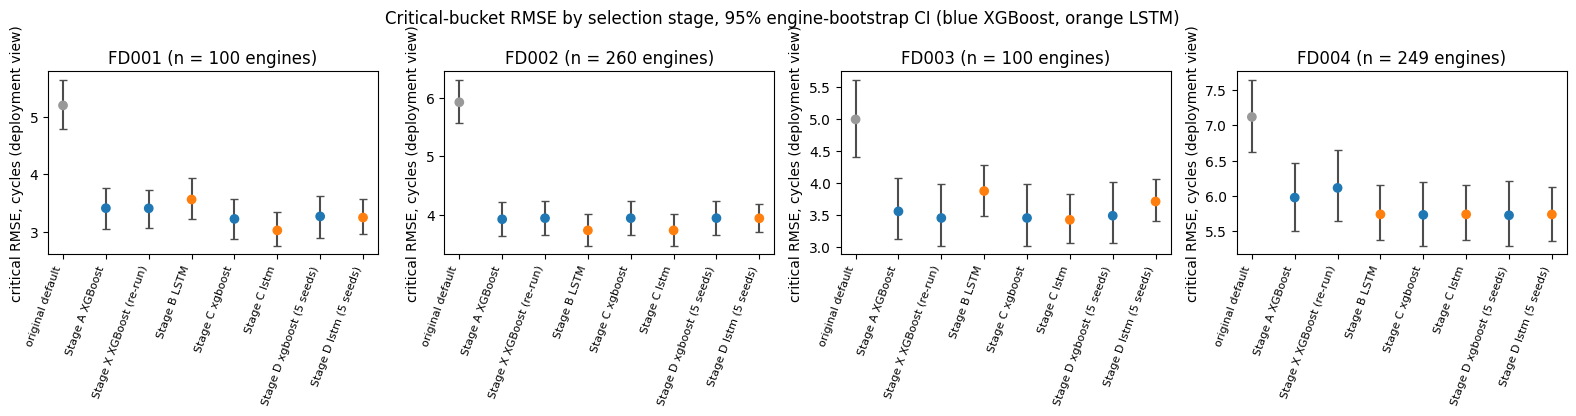

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharey=False)
for ax, ds in zip(axes, DATASETS):
    p = prog[prog["dataset"] == ds].reset_index(drop=True)
    colors = ["0.6" if "default" in c else ("tab:orange" if "lstm" in c.lower() else "tab:blue")
              for c in p["candidate"]]
    ax.errorbar(range(len(p)), p["est"], yerr=[p["est"] - p["lo"], p["hi"] - p["est"]], fmt="none",
                ecolor="0.3", capsize=3)
    ax.scatter(range(len(p)), p["est"], c=colors, zorder=3)
    ax.set_xticks(range(len(p)), p["candidate"], rotation=70, ha="right", fontsize=8)
    ax.set_title(f"{ds} (n = {p['n engines'].iloc[0]} engines)")
    ax.set_ylabel("critical RMSE, cycles (deployment view)")
fig.suptitle("Critical-bucket RMSE by selection stage, 95% engine-bootstrap CI "
             "(blue XGBoost, orange LSTM)")
fig.tight_layout()
fig.savefig(FIG / "progression.png", dpi=100)
plt.show()

In [ ]:
gain = {ds: prog[(prog.dataset == ds) & (prog.candidate == "original default")].est.iloc[0]
        - prog[(prog.dataset == ds) & prog.candidate.str.startswith("Stage D")].est.min()
        for ds in DATASETS}
assert all(g > 0 for g in gain.values())
print("Best Stage D finalist vs original default, point estimates (cycles): "
      + ", ".join(f"{ds} −{g:.2f}" for ds, g in gain.items()))

Best Stage D finalist vs original default, point estimates (cycles): FD001 −1.95, FD002 −1.99, FD003 −1.51, FD004 −1.39


**Takeaway:** every dataset's best 5-seed finalist sits below the original default (asserted
and printed above); the figure shows where along the stages each gain arrived (D51).

## 2. Is cap 90 an artefact of the metric?

**Question:** critical RMSE favours a narrower training target by construction — does cap 90 also
win where no cap binds?
**Method:** the pre-registered A1-check on the Stage A runs (urgent-bucket RMSE, critical / urgent
late % vs uncapped truth, matched-budget decision check), repeated at 5 seeds in Stage D's
leave-one-out of the cap.

In [ ]:
a1 = json.loads((SEL / "a1_check.json").read_text(encoding="utf-8"))
rows = []
for ds, d in a1["datasets"].items():
    for r in d["comparisons"]:
        rows.append({"dataset": ds, "source": "A1-check (seed 42)", "metric": r["metric"],
                     "Δ cap 90 − 125 [95% CI]": ci(r["diff"], r["diff_ci_lo"], r["diff_ci_hi"]),
                     "worse": r["worse"]})
dcap = comparisons("D", "D-cap")
for r in dcap.to_dict("records"):
    rows.append({"dataset": r["dataset"], "source": f"Stage D {r['step'][6:]} (5 seeds)",
                 "metric": r["metric"], "Δ cap 90 − 125 [95% CI]": r["Δ [95% CI]"],
                 "worse": r["verdict"] == "worse"})
capt = pd.DataFrame(rows)
worse = capt[capt["worse"]]
assert a1["confirmed"]
assert not worse["source"].str.contains("xgboost").any()  # the XGBoost cap holds at 5 seeds
assert set(worse["dataset"] + " " + worse["source"]) == {"FD003 Stage D lstm (5 seeds)"}
capt

,dataset,source,metric,Δ cap 90 − 125 [95% CI],worse
0,FD001,A1-check (seed 42),urgent_rmse,"-2.45 [-3.32, -1.61]",False
1,FD001,A1-check (seed 42),critical_late_pct,"-3.37 [-4.77, -2.00]",False
2,FD001,A1-check (seed 42),urgent_late_pct,"-0.71 [-2.01, 0.44]",False
3,FD002,A1-check (seed 42),urgent_rmse,"-3.35 [-3.95, -2.78]",False
4,FD002,A1-check (seed 42),critical_late_pct,"-2.49 [-3.23, -1.77]",False
5,FD002,A1-check (seed 42),urgent_late_pct,"-0.11 [-0.76, 0.52]",False
6,FD003,A1-check (seed 42),urgent_rmse,"-2.12 [-3.09, -1.18]",False
7,FD003,A1-check (seed 42),critical_late_pct,"-3.63 [-5.05, -2.21]",False
8,FD003,A1-check (seed 42),urgent_late_pct,"-2.07 [-3.80, -0.52]",False
9,FD004,A1-check (seed 42),urgent_rmse,"-2.75 [-3.37, -2.16]",False


**Takeaway:** for XGBoost, cap 90 is not worse than 125 on any metric no cap binds, at one seed
or at five, so it is kept (D01). **One contradiction (rule 9, X08):** the FD003 LSTM at cap 90 is
later on critical and urgent late % at five seeds (asserted above), so its cap reverts to 125 by
the pre-registered rule — the cap-90 confirmation of the A1-check does not transfer to every model.

## 3. Which addendum blocks survived?

**Question:** do longer windows, the early-life baseline deviation or the early subpopulation
probability improve the Stage A XGBoost spec?
**Method:** pre-registered after Stage A (`ba0f6ba`): each challenger vs a re-run of its
incumbent under the current code, paired engine bootstrap; adopted only if the CI is below 0.

In [ ]:
xt = comparisons("X")
assert not (xt["verdict"] == "better").any()
show(xt)

,dataset,step,metric,challenger,incumbent,Δ [95% CI],n engines,verdict
0,FD001,A2-ext,critical_rmse,"xgboost, cap 90, window 60","xgboost, cap 90, window 45","-0.21 [-0.46, 0.05]",100,not different
1,FD001,A2-ext,critical_rmse,"xgboost, cap 90, window 90","xgboost, cap 90, window 45","0.16 [-0.27, 0.55]",100,not different
2,FD001,A5a,critical_rmse,"xgboost, cap 90, window 45, hi_pooled, baseline","xgboost, cap 90, window 45, hi_pooled","-0.01 [-0.21, 0.22]",100,not different
3,FD002,A2-ext,critical_rmse,"xgboost, cap 90, window 60","xgboost, cap 90, window 45","-0.08 [-0.28, 0.13]",260,not different
4,FD002,A2-ext,critical_rmse,"xgboost, cap 90, window 90","xgboost, cap 90, window 45","0.20 [-0.06, 0.47]",260,not different
5,FD002,A5a,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, baseline","xgboost, cap 90, window 45, hi_consistent","0.36 [0.11, 0.62]",260,worse
6,FD003,A2-ext,critical_rmse,"xgboost, cap 90, window 60","xgboost, cap 90, window 45","-0.15 [-0.67, 0.24]",100,not different
7,FD003,A2-ext,critical_rmse,"xgboost, cap 90, window 90","xgboost, cap 90, window 45","0.29 [-0.19, 0.72]",100,not different
8,FD003,A5a,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, baseline","xgboost, cap 90, window 45, hi_consistent","0.63 [0.17, 1.19]",100,worse
9,FD003,A5b,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, subpop_prob","xgboost, cap 90, window 45, hi_consistent","0.21 [0.10, 0.34]",100,worse


**Takeaway:** no addendum challenger beats its incumbent (asserted); windows 60 / 90 are not
different, the two new blocks are worse or not different, so the Stage A specs carry on unchanged.
The subpopulation is identifiable from 30 cycles on FD003/FD004, yet knowing it does not help the
critical zone (D35).

## 4. LSTM: sequence length and channels

**Question:** which sequence length, and do the regime indicators or the health-index score help
the LSTM?
**Method:** Stage B, one factor at a time at cap 90 and seed 42; `seq_len` incumbent 30.

In [ ]:
bt = comparisons("B")
show(bt)

,dataset,step,metric,challenger,incumbent,Δ [95% CI],n engines,verdict
0,FD001,B1,critical_rmse,"lstm, cap 90, seq_len 20","lstm, cap 90, seq_len 30","1.43 [0.88, 1.95]",100,worse
1,FD001,B1,critical_rmse,"lstm, cap 90, seq_len 45","lstm, cap 90, seq_len 30","-0.47 [-0.72, -0.22]",100,better
2,FD001,B1,critical_rmse,"lstm, cap 90, seq_len 60","lstm, cap 90, seq_len 30","-0.53 [-0.83, -0.26]",100,better
3,FD001,B2,critical_rmse,"lstm, cap 90, seq_len 60, hi_pooled","lstm, cap 90, seq_len 60","0.04 [-0.24, 0.34]",100,not different
4,FD002,B1,critical_rmse,"lstm, cap 90, seq_len 20","lstm, cap 90, seq_len 30","1.32 [1.00, 1.65]",260,worse
5,FD002,B1,critical_rmse,"lstm, cap 90, seq_len 45","lstm, cap 90, seq_len 30","-0.63 [-0.86, -0.39]",260,better
6,FD002,B1,critical_rmse,"lstm, cap 90, seq_len 60","lstm, cap 90, seq_len 30","-0.86 [-1.15, -0.58]",260,better
7,FD002,B2,critical_rmse,"lstm, cap 90, seq_len 60, regime_onehot","lstm, cap 90, seq_len 60","0.02 [-0.14, 0.19]",260,not different
8,FD002,B2,critical_rmse,"lstm, cap 90, seq_len 60, hi_consistent","lstm, cap 90, seq_len 60","0.57 [0.37, 0.78]",260,worse
9,FD003,B1,critical_rmse,"lstm, cap 90, seq_len 20","lstm, cap 90, seq_len 30","1.11 [0.63, 1.60]",100,worse


In [ ]:
b_adopt = {ds: Spec.from_json(load("B", ds)["specs"]["lstm"]) for ds in DATASETS}
assert all(not s.blocks for s in b_adopt.values())
print("Stage B LSTM per dataset: "
      + "; ".join(f"{ds} seq_len {s.seq_len}" for ds, s in b_adopt.items()))

Stage B LSTM per dataset: FD001 seq_len 60; FD002 seq_len 60; FD003 seq_len 30; FD004 seq_len 30


**Takeaway:** sequence length matters (20 is worse everywhere), the channel blocks never help —
no LSTM keeps one (asserted) (D10). 60 is the grid edge where it wins; that limitation stays open.

## 5. What did tuning buy?

**Question:** does Optuna improve the stage-B configs beyond noise?
**Method:** TPE on the repeat-1 folds; the best trial vs the untuned config on repeats 2–3 only.
Optimistic by construction: those engines tuned the config in some repeat-1 fold.

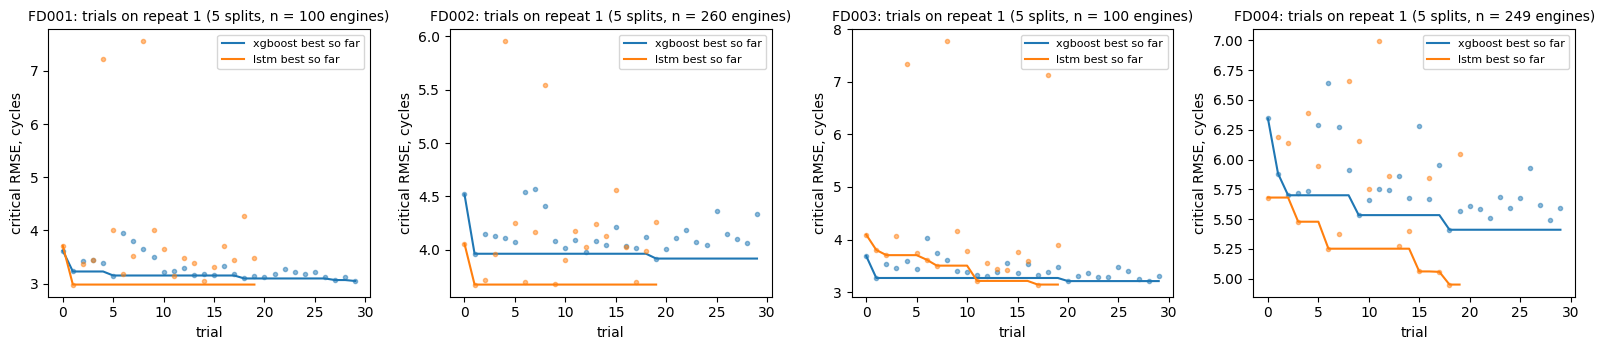

,dataset,step,metric,challenger,incumbent,Δ [95% CI],n engines,verdict
0,FD001,C-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_pooled, tuned","xgboost, cap 90, window 45, hi_pooled","-0.17 [-0.28, -0.07]",100,better
1,FD001,C-lstm,critical_rmse,"lstm, cap 90, seq_len 60, tuned","lstm, cap 90, seq_len 60","-0.72 [-1.10, -0.35]",100,better
2,FD002,C-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, tuned","xgboost, cap 90, window 45, hi_consistent","0.12 [-0.02, 0.27]",260,not different
3,FD002,C-lstm,critical_rmse,"lstm, cap 90, seq_len 60, tuned","lstm, cap 90, seq_len 60","0.03 [-0.19, 0.24]",260,not different
4,FD003,C-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, tuned","xgboost, cap 90, window 45, hi_consistent","-0.11 [-0.27, 0.03]",100,not different
5,FD003,C-lstm,critical_rmse,"lstm, cap 90, seq_len 30, tuned","lstm, cap 90, seq_len 30","-0.31 [-0.62, -0.01]",100,better
6,FD004,C-xgboost,critical_rmse,"xgboost, cap 90, window 30, hi_consistent, regime_onehot, tuned","xgboost, cap 90, window 30, hi_consistent, regime_onehot","-0.33 [-0.47, -0.21]",249,better
7,FD004,C-lstm,critical_rmse,"lstm, cap 90, seq_len 30, tuned","lstm, cap 90, seq_len 30","0.15 [-0.17, 0.46]",249,not different


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, ds in zip(axes, DATASETS):
    for m, col in (("xgboost", "tab:blue"), ("lstm", "tab:orange")):
        t = pd.DataFrame(load("C", ds)["extra"]["tuning"][m]["trials"])
        ax.plot(t["trial"], t[HEAD], ".", color=col, alpha=0.5)
        ax.plot(t["trial"], t[HEAD].cummin(), "-", color=col, label=f"{m} best so far")
    n = prog[prog.dataset == ds]["n engines"].iloc[0]
    ax.set_title(f"{ds}: trials on repeat 1 (5 splits, n = {n} engines)", fontsize=10)
    ax.set_xlabel("trial")
    ax.set_ylabel("critical RMSE, cycles")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "tuning.png", dpi=100)
plt.show()
show(comparisons("C"))

**Takeaway:** tuning is adopted only where its repeats-2/3 CI excludes 0 (table); its gains are
smaller than Stage A's and, by design, optimistic (D21, D22).

## 6. Which adopted changes survive five seeds?

**Question:** with 5 seeds × 15 splits, does each adopted change still beat the spec without it?
**Method:** pre-registered leave-one-out: Δ = finalist − finalist minus the change; a change whose
CI includes 0 is dropped (parsimony).

In [ ]:
loo = comparisons("D", "D-LOO")
print({ds: load("D", ds)["extra"]["loo"] for ds in DATASETS})
show(loo)

{'FD001': {'xgboost': {'changes': ['cap', 'window', 'hi_pooled', 'tuning'], 'dropped': []}, 'lstm': {'changes': ['cap', 'seq_len', 'tuning'], 'dropped': []}}, 'FD002': {'xgboost': {'changes': ['cap', 'window', 'hi_consistent'], 'dropped': []}, 'lstm': {'changes': ['cap', 'seq_len'], 'dropped': []}}, 'FD003': {'xgboost': {'changes': ['cap', 'window', 'hi_consistent'], 'dropped': []}, 'lstm': {'changes': ['cap', 'tuning'], 'dropped': ['cap']}}, 'FD004': {'xgboost': {'changes': ['cap', 'window', 'hi_consistent', 'regime_onehot', 'tuning'], 'dropped': ['regime_onehot']}, 'lstm': {'changes': ['cap'], 'dropped': []}}}


,dataset,step,metric,challenger,incumbent,Δ [95% CI],n engines,verdict
0,FD001,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_pooled, tuned, 5 seeds","xgboost, cap 125, window 45, hi_pooled, tuned, 5 seeds","-0.36 [-0.58, -0.19]",100,better
1,FD001,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_pooled, tuned, 5 seeds","xgboost, cap 90, window 20, hi_pooled, tuned, 5 seeds","-1.08 [-1.44, -0.73]",100,better
2,FD001,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_pooled, tuned, 5 seeds","xgboost, cap 90, window 45, tuned, 5 seeds","-0.51 [-0.79, -0.27]",100,better
3,FD001,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_pooled, tuned, 5 seeds","xgboost, cap 90, window 45, hi_pooled, 5 seeds","-0.09 [-0.17, -0.01]",100,better
4,FD001,D-LOO-lstm,critical_rmse,"lstm, cap 90, seq_len 60, tuned, 5 seeds","lstm, cap 125, seq_len 60, tuned, 5 seeds","-0.50 [-0.67, -0.35]",100,better
5,FD001,D-LOO-lstm,critical_rmse,"lstm, cap 90, seq_len 60, tuned, 5 seeds","lstm, cap 90, seq_len 30, tuned, 5 seeds","-0.50 [-0.76, -0.25]",100,better
6,FD001,D-LOO-lstm,critical_rmse,"lstm, cap 90, seq_len 60, tuned, 5 seeds","lstm, cap 90, seq_len 60, 5 seeds","-0.38 [-0.51, -0.25]",100,better
7,FD002,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, 5 seeds","xgboost, cap 125, window 45, hi_consistent, 5 seeds","-0.41 [-0.54, -0.30]",260,better
8,FD002,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, 5 seeds","xgboost, cap 90, window 20, hi_consistent, 5 seeds","-1.59 [-1.94, -1.25]",260,better
9,FD002,D-LOO-xgboost,critical_rmse,"xgboost, cap 90, window 45, hi_consistent, 5 seeds","xgboost, cap 90, window 45, 5 seeds","-0.19 [-0.34, -0.04]",260,better


## 7. XGBoost or LSTM — and is it locked?

**Question:** which finalist wins on critical RMSE, and does the decision check agree?
**Method:** paired Δ (LSTM − XGBoost) over 5 seeds × 15 splits; a tie goes to XGBoost (simpler);
locked only if the decision check (caught % at matched wasted life) supports the single winner,
else both locked-pending.

In [ ]:
rows = []
for ds in DATASETS:
    d = load("D", ds)
    fin = [r for r in d["comparisons"] if r["substage"] == "D-final"][0]
    dc = [r for r in d["decisions"] if r["substage"] == "D-final"]
    out = d["extra"]["outcome"]
    rows.append({"dataset": ds,
                 "Δ LSTM − XGBoost [95% CI]": ci(fin["diff"], fin["diff_ci_lo"], fin["diff_ci_hi"]),
                 "decision Δ caught pp (20/30/40)": "; ".join(
                     ci(r["diff"], r["diff_ci_lo"], r["diff_ci_hi"], 1) for r in dc),
                 "winner": out["winner"], "locked": out["locked"], "reason": out["reason"]})
final = pd.DataFrame(rows)
final

,dataset,Δ LSTM − XGBoost [95% CI],decision Δ caught pp (20/30/40),winner,locked,reason
0,FD001,"-0.02 [-0.34, 0.28]","-0.2 [-4.1, 3.8]; 1.8 [-0.7, 4.5]; 0.0 [0.0, 0.0]",xgboost,True,tie on critical RMSE: XGBoost (simpler) wins; decision check agrees -> locked
1,FD002,"-0.00 [-0.27, 0.27]","-1.3 [-3.7, 0.9]; -1.2 [-2.3, -0.0]; -0.1 [-0.2, 0.0]",xgboost,True,tie on critical RMSE: XGBoost (simpler) wins; decision check agrees -> locked
2,FD003,"0.22 [-0.33, 0.77]","-6.4 [-11.5, -1.5]; -2.2 [-4.2, -0.3]; 0.0 [0.0, 0.0]",xgboost,True,tie on critical RMSE: XGBoost (simpler) wins; decision check agrees -> locked
3,FD004,"0.01 [-0.31, 0.31]","-1.1 [-3.9, 3.3]; -1.3 [-4.7, 0.9]; -0.3 [-0.7, 0.0]",xgboost,True,tie on critical RMSE: XGBoost (simpler) wins; decision check agrees -> locked


In [ ]:
for ds in DATASETS:
    for m in ("xgboost", "lstm"):
        p = REPO / "specs" / f"{ds}_{m}.yaml"
        s = yaml.safe_load(p.read_text(encoding="utf-8"))
        print(f"{p.name}: locked={s['locked']} status={s['status']} cap={s['rul_cap']} "
              f"window={s['window']} seq_len={s['seq_len']} features={s['features']} "
              f"tuned={bool(s['model_params'])}")
lstm_wins = [r.dataset for r in final.itertuples() if r.winner == "lstm"]
print(f"D25 ('ship the LSTM'): the LSTM wins on {lstm_wins or 'no dataset'} of {DATASETS}.")

FD001_xgboost.yaml: locked=True status=locked cap=90 window=45 seq_len=30 features={'health_index': 'pooled', 'regime_onehot': False, 'extra_sensors': [], 'baseline': False, 'subpop_prob': False} tuned=True
FD001_lstm.yaml: locked=False status=runner-up cap=90 window=45 seq_len=60 features={'health_index': 'none', 'regime_onehot': False, 'extra_sensors': [], 'baseline': False, 'subpop_prob': False} tuned=True
FD002_xgboost.yaml: locked=True status=locked cap=90 window=45 seq_len=30 features={'health_index': 'consistent', 'regime_onehot': False, 'extra_sensors': [], 'baseline': False, 'subpop_prob': False} tuned=False
FD002_lstm.yaml: locked=False status=runner-up cap=90 window=45 seq_len=60 features={'health_index': 'none', 'regime_onehot': False, 'extra_sensors': [], 'baseline': False, 'subpop_prob': False} tuned=False
FD003_xgboost.yaml: locked=True status=locked cap=90 window=45 seq_len=30 features={'health_index': 'consistent', 'regime_onehot': False, 'extra_sensors': [], 'baseline

**Takeaway:** the outcome per dataset is the table above, computed from the pre-registered rules;
D25's test-set claim is re-decided here on training engines only (printed line). `params.yaml`
defaults are not changed and `final_eval` is not run — both are later, reviewed steps (D51).

**If asked to defend this:** a tie going to XGBoost is the pre-registered simplicity rule, not a
claim that XGBoost is more accurate; the LSTM remains within the CI.

## Limitations

- One factor at a time: cap × window × features interactions are untested (except Stage D's
  leave-one-out, which tests each change in the context of the final spec).
- Screening (A–C) at one seed with ~70 uncorrected comparisons; only Stage D's 5-seed tests decide.
- Tuning optimism (repeats reuse the tuning engines); `seq_len` 60 is a grid edge on FD001/FD002.
- All evidence is CV on training engines; the sealed test read (`final_eval`) comes after review.